In [1]:
import pandas as pd

In [2]:
feature_df_name = 'fifth_feature_df_14_01_2026.csv'

training_df = pd.read_csv(feature_df_name)

In [6]:
training_df.columns

Index(['GCS_max', 'GCS_mean', 'Lactate_min', 'Lactate_max', 'Lactate_mean',
       'BUN_min', 'BUN_mean', 'BUN_max', 'Bilirubin_max', 'Bilirubin_mean',
       'Albumin_mean', 'Albumin_min', 'Albumin_max', 'AlkPhos_mean',
       'AlkPhos_max', 'AlkPhos_min', 'PT_mean', 'PT_min', 'INR_mean',
       'INR_min', 'Phosphate_mean', 'Phosphate_max', 'PaO2_mean', 'PaO2_max',
       'aPTT_mean', 'aPTT_min', 'MORTALITY_INHOSPITAL', 'MORTALITY_90DAY',
       'MORTALITY_180DAY', 'AG_mean', 'AG_max', 'AG_min', 'AG_std',
       'SYSBP_min', 'SYSBP_mean', 'SYSBP_std', 'DIASBP_min', 'DIASBP_mean',
       'age', 'RR_mean', 'RR_max', 'RR_min', 'TEMP_std', 'TEMP_min', 'HR_mean',
       'HR_max', 'HR_std', 'RDW_max', 'RDW_mean', 'RDW_min', 'RDW_std',
       'age_adj_comorbidity_score', 'MEANBP_min', 'MEANBP_mean'],
      dtype='str')

C:\Users\maxim\AppData\Local\Temp\ipykernel_12516\2875473882.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


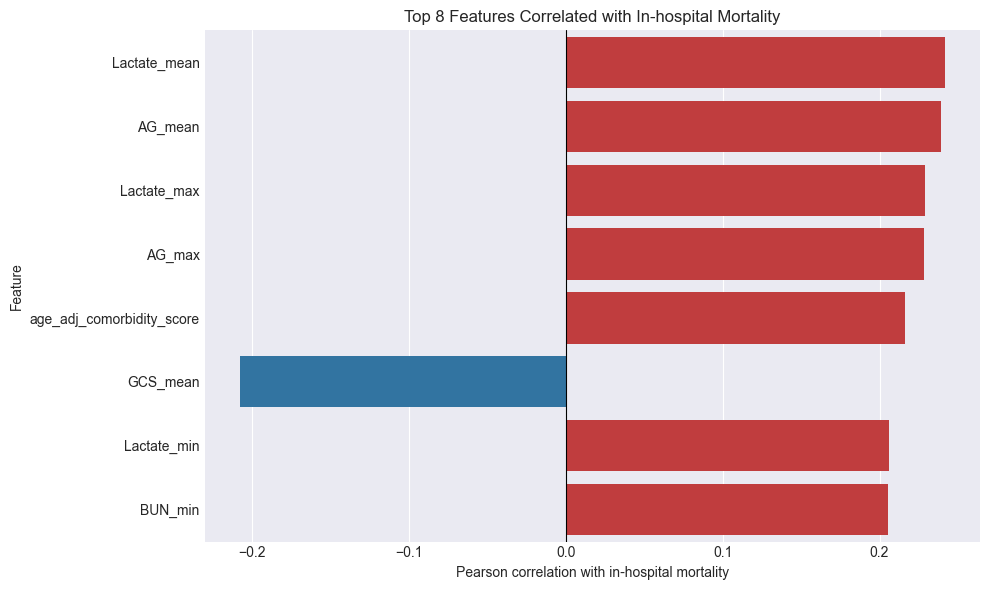

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_df_name = 'fifth_feature_df_14_01_2026.csv'
training_df = pd.read_csv(feature_df_name)

# Drop ID columns if present
id_cols = ['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'MORTALITY_90DAY', 'MORTALITY_180DAY']
training_df = training_df.drop(columns=[c for c in id_cols if c in training_df.columns])

# Define mortality column (adjust if your name differs)
mortality_col = 'MORTALITY_INHOSPITAL'  # or your actual column name

# Keep only numeric columns
numeric_df = training_df.select_dtypes(include=[np.number])

# Correlation with in‑hospital mortality
corr_series = numeric_df.corr()[mortality_col].drop(labels=[mortality_col])

# Take top 8 by absolute correlation, but preserve sign
top8 = corr_series.reindex(corr_series.abs().sort_values(ascending=False).head(8).index)

# Optional: save table
corr_results = top8.reset_index()
corr_results.columns = ['feature', 'correlation_with_mortality']
corr_results.to_csv('top8_mortality_correlations.csv', index=False)

# Nice plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top8.values,
    y=top8.index,
    palette=['#d62728' if v > 0 else '#1f77b4' for v in top8.values]
)
plt.xlabel('Pearson correlation with in-hospital mortality')
plt.ylabel('Feature')
plt.title('Top 8 Features Correlated with In-hospital Mortality')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
